# Business Performance Diagnosis

## Overview : Analyze retail business performance using Sample Superstore dataset

## Project Objectives : 
### 1.Sales Performance Analysis
### 2.Profitability Analysis
### 3.Product Performance Analysis
### 4.Regional Analysis
### 5.Customer Analysis
### 6.Discount Impact Analysis
### 7.Shipping Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load dataset
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 21)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [6]:
# Data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


# Data Cleaning 

In [8]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
df.isnull().sum().sum()

0

In [10]:
df.duplicated().sum()

0

In [11]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [12]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [13]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [14]:
print("Categories:", df["Category"].unique())
print("Regions:", df["Region"].unique())
print("Segnments:", df["Segment"].unique())
print("Ship Modes:", df["Ship Mode"].unique())

Categories: ['Furniture' 'Office Supplies' 'Technology']
Regions: ['South' 'West' 'Central' 'East']
Segnments: ['Consumer' 'Corporate' 'Home Office']
Ship Modes: ['Second Class' 'Standard Class' 'First Class' 'Same Day']


In [15]:
df[["Sales", "Profit", "Quantity", "Discount"]].describe()

,Sales,Profit,Quantity,Discount
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,3.789574,0.156203
std,623.245101,234.260108,2.225110,0.206452
min,0.444000,-6599.978000,1.000000,0.000000
25%,17.280000,1.728750,2.000000,0.000000
50%,54.490000,8.666500,3.000000,0.200000
75%,209.940000,29.364000,5.000000,0.200000
max,22638.480000,8399.976000,14.000000,0.800000


# Create Cleaned Dataset

In [18]:
df.to_csv("Superstore_Cleaned.csv", index=False)

In [19]:
df.shape

(9994, 21)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

# Business Performance Analysis 

In [21]:
# Total Sales 
total_sales = df["Sales"].sum()
print("Total Sales:", total_sales)

Total Sales: 2297200.8603000003


In [23]:
# Total Profit 
total_profit = df["Profit"].sum()
print("Total Profit:",total_profit)

Total Profit: 286397.0217


In [25]:
# Total Orders 
total_orders = df["Order ID"].nunique()
print("Total Orders:", total_orders)

Total Orders: 5009


In [26]:
# Total Customers
total_customers = df["Customer ID"].nunique()
print("Total Customers:", total_customers)

Total Customers: 793


In [29]:
# Average Discount
avg_discount = df["Discount"].mean()
print("Average Discount:", avg_discount)
print("Average Discount:", round(avg_discount * 100, 2), "%")

Average Discount: 0.15620272163297977
Average Discount: 15.62 %


In [30]:
profit_margin = (total_profit / total_sales) * 100
print("Profit Margin:", round(profit_margin, 2), "%")

Profit Margin: 12.47 %


In [31]:
# All Six business KPIs
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Total Customers",
        "Average Discount",
        "Profit Margin"
    ],
    "Value": [
        total_sales,
        total_profit,
        total_orders,
        total_customers,
        avg_discount,
        profit_margin
    ]
})

kpi_summary

,KPI,Value
0,Total Sales,2.297201e+06
1,Total Profit,2.863970e+05
2,Total Orders,5.009000e+03
3,Total Customers,7.930000e+02
4,Average Discount,1.562027e-01
5,Profit Margin,1.246722e+01


# Analysis1: Sales and Proft Trends

In [32]:
#Extract year from Order Date (create Year Column)
df["Year"] = df["Order Date"].dt.year
df[["Order Date", "Year"]].head()

,Order Date,Year
0,2016-11-08,2016
1,2016-11-08,2016
2,2016-06-12,2016
3,2015-10-11,2015
4,2015-10-11,2015


In [34]:
#Calculate Yearly Sales and Profit
yearly_performance = df.groupby("Year").agg({
    "Sales": "sum",
    "Profit": "sum"
}).reset_index()

yearly_performance

,Year,Sales,Profit
0,2014,484247.4981,49543.9741
1,2015,470532.5090,61618.6037
2,2016,609205.5980,81795.1743
3,2017,733215.2552,93439.2696


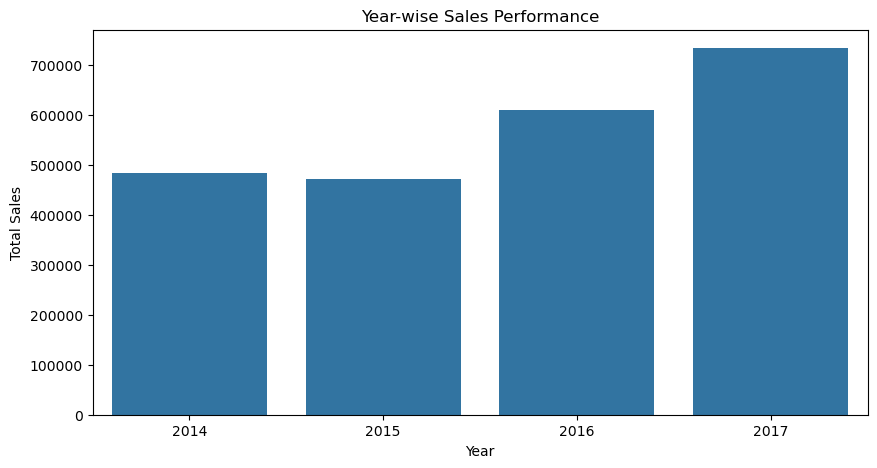

In [35]:
# Visualize Yearly Sales
plt.figure(figsize=(10,5))

sns.barplot(
    data=yearly_performance,
    x="Year",
    y="Sales"
)

plt.title("Year-wise Sales Performance")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

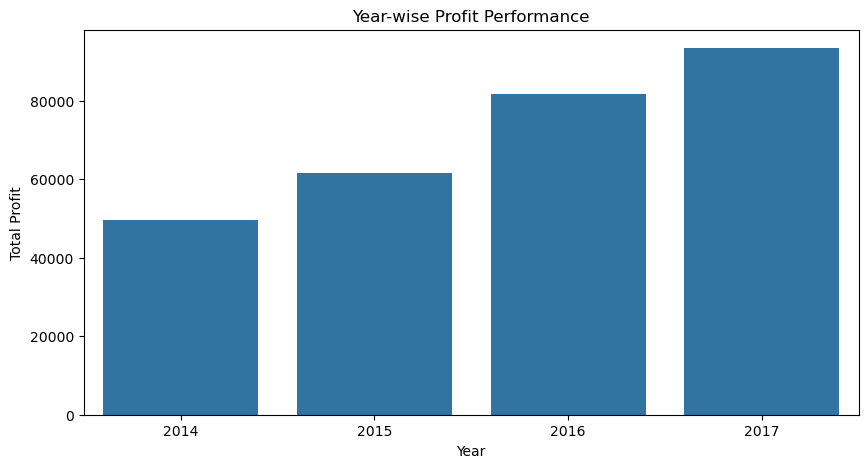

In [37]:
# Visualize Yearly Profit
plt.figure(figsize=(10,5))

sns.barplot(
    data=yearly_performance,
    x="Year",
    y="Profit"
)

plt.title("Year-wise Profit Performance")
plt.xlabel("Year")
plt.ylabel("Total Profit")
plt.show()

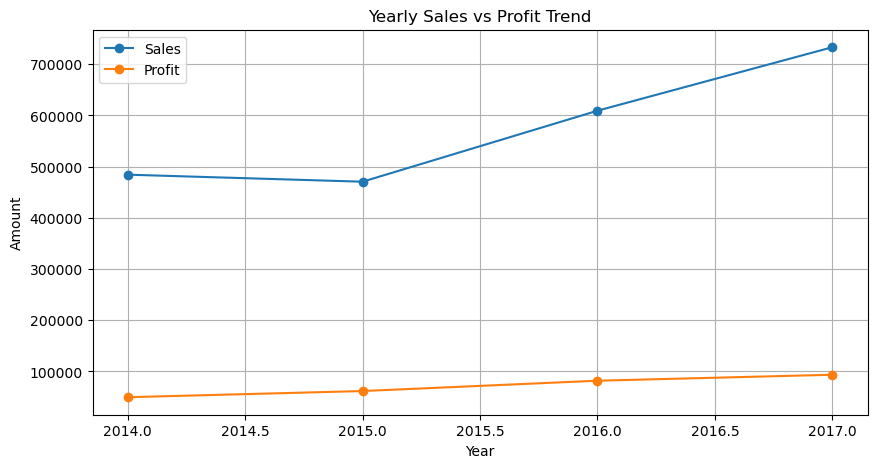

In [38]:
#Compare sales and profit together
plt.figure(figsize=(10,5))

plt.plot(
    yearly_performance["Year"],
    yearly_performance["Sales"],
    marker="o",
    label="Sales"
)

plt.plot(
    yearly_performance["Year"],
    yearly_performance["Profit"],
    marker="o",
    label="Profit"
)

plt.title("Yearly Sales vs Profit Trend")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend()
plt.grid(True)
plt.show()


In [39]:
# Best Performing Year
best_sales_year = yearly_performance.loc[
    yearly_performance["Sales"].idxmax()
]

best_profit_year = yearly_performance.loc[
    yearly_performance["Profit"].idxmax()
]

print("Highest Sales Year:")
print(best_sales_year)

print("\nHighest Profit Year:")
print(best_profit_year)


Highest Sales Year:
Year        2017.0000
Sales     733215.2552
Profit     93439.2696
Name: 3, dtype: float64

Highest Profit Year:
Year        2017.0000
Sales     733215.2552
Profit     93439.2696
Name: 3, dtype: float64


# Analysis2 : Product Performance (Category & Sub-category Analysis)

In [40]:
# Category-wise performance
category_performance = df.groupby("Category").agg({
    "Sales": "sum",
    "Profit": "sum"
}).reset_index()

category_performance["Profit Margin"] = (
    category_performance["Profit"] /
    category_performance["Sales"]
) * 100

category_performance

,Category,Sales,Profit,Profit Margin
0,Furniture,741999.7953,18451.2728,2.486695
1,Office Supplies,719047.0320,122490.8008,17.035158
2,Technology,836154.0330,145454.9481,17.395712


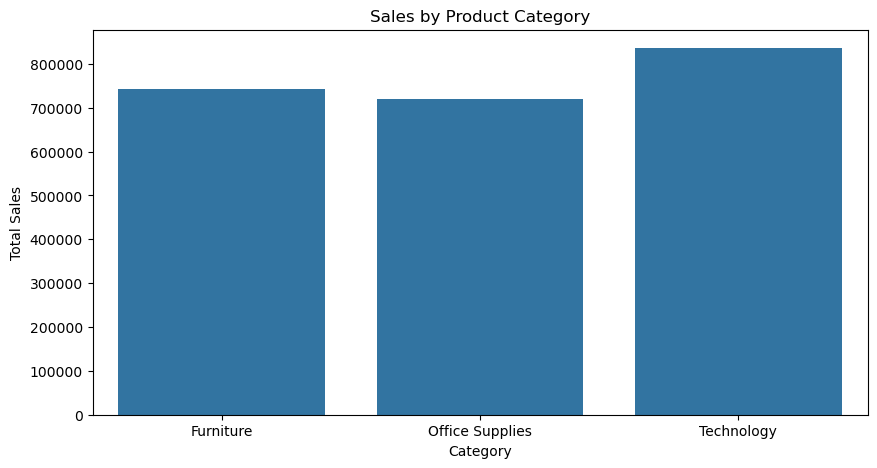

In [41]:
# Create a combined visualization
plt.figure(figsize=(10,5))

sns.barplot(
    data=category_performance,
    x="Category",
    y="Sales"
)

plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

In [42]:
# Sub-category performance
subcategory_performance = df.groupby("Sub-Category").agg({
    "Sales": "sum",
    "Profit": "sum"
}).reset_index()

subcategory_performance = subcategory_performance.sort_values(
    by="Profit",
    ascending=False
)

subcategory_performance

,Sub-Category,Sales,Profit
6,Copiers,149528.0300,55617.8249
13,Phones,330007.0540,44515.7306
0,Accessories,167380.3180,41936.6357
12,Paper,78479.2060,34053.5693
3,Binders,203412.7330,30221.7633
5,Chairs,328449.1030,26590.1663
14,Storage,223843.6080,21278.8264
1,Appliances,107532.1610,18138.0054
9,Furnishings,91705.1640,13059.1436
7,Envelopes,16476.4020,6964.1767


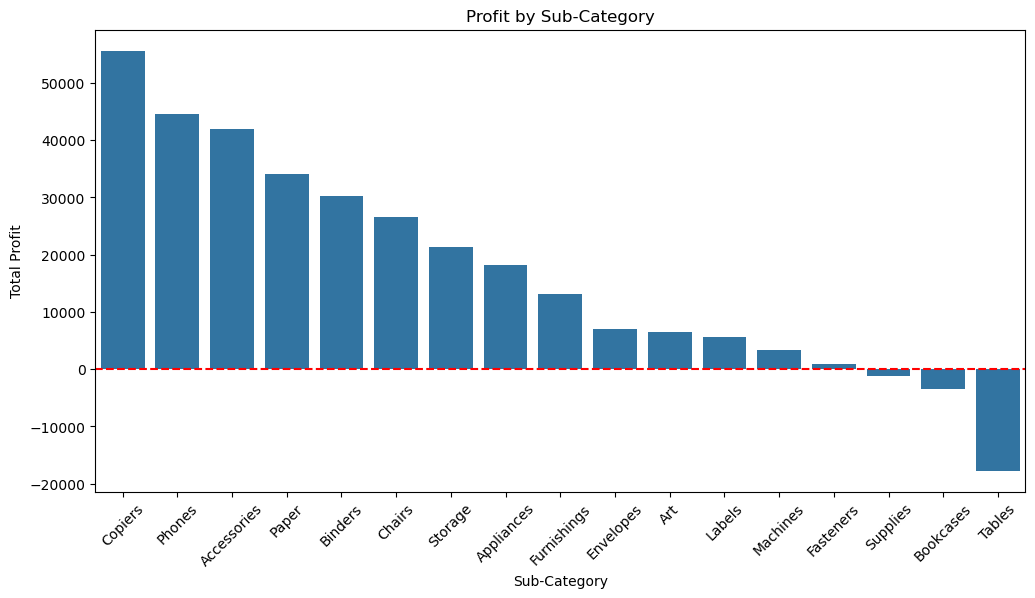

In [43]:
# Visualize sub-category profit
plt.figure(figsize=(12,6))

sns.barplot(
    data=subcategory_performance,
    x="Sub-Category",
    y="Profit"
)

plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)
plt.axhline(y=0, color="red", linestyle="--")

plt.show()

In [44]:
# Identify business problems
print("Highest Sales Category:")
print(category_performance.loc[category_performance["Sales"].idxmax(), "Category"])

print("\nHighest Profit Category:")
print(category_performance.loc[category_performance["Profit"].idxmax(), "Category"])

print("\nMost Profitable Sub-Category:")
print(subcategory_performance.iloc[0]["Sub-Category"])

print("\nLowest Profit Sub-Category:")
print(subcategory_performance.iloc[-1]["Sub-Category"])

Highest Sales Category:
Technology

Highest Profit Category:
Technology

Most Profitable Sub-Category:
Copiers

Lowest Profit Sub-Category:
Tables


# Analysis 3 – Regional Performance

In [45]:
# Regional performance
region_performance = df.groupby("Region").agg({
    "Sales": "sum",
    "Profit": "sum"
}).reset_index()

region_performance

,Region,Sales,Profit
0,Central,501239.8908,39706.3625
1,East,678781.2400,91522.7800
2,South,391721.9050,46749.4303
3,West,725457.8245,108418.4489


In [46]:
# Calculate profit margin
region_performance["Profit Margin"] = (
    region_performance["Profit"] /
    region_performance["Sales"]
) * 100

region_performance

,Region,Sales,Profit,Profit Margin
0,Central,501239.8908,39706.3625,7.921629
1,East,678781.2400,91522.7800,13.483399
2,South,391721.9050,46749.4303,11.934342
3,West,725457.8245,108418.4489,14.944831


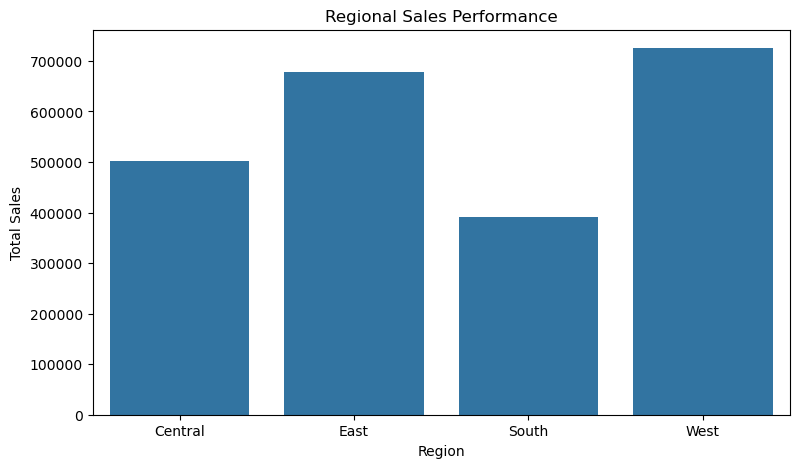

In [47]:
# Visualize regional sales
plt.figure(figsize=(9,5))

sns.barplot(
    data=region_performance,
    x="Region",
    y="Sales"
)

plt.title("Regional Sales Performance")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

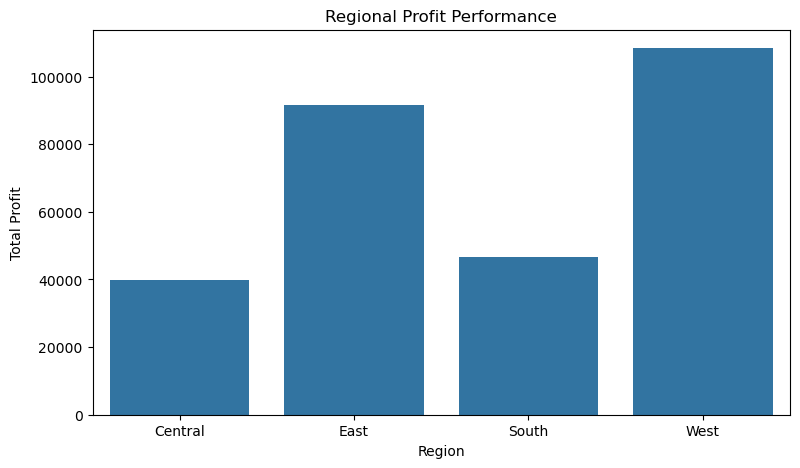

In [48]:
# Visualize regional profit
plt.figure(figsize=(9,5))

sns.barplot(
    data=region_performance,
    x="Region",
    y="Profit"
)

plt.title("Regional Profit Performance")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.show()

In [49]:
# Identify the best and worst regions
print("Highest Sales Region:")
print(region_performance.loc[region_performance["Sales"].idxmax(), "Region"])

print("\nHighest Profit Region:")
print(region_performance.loc[region_performance["Profit"].idxmax(), "Region"])

print("\nLowest Profit Region:")
print(region_performance.loc[region_performance["Profit"].idxmin(), "Region"])


Highest Sales Region:
West

Highest Profit Region:
West

Lowest Profit Region:
Central


# Analysis 4: Discount Impact on Profit

In [50]:
# Understand discount values
df["Discount"].unique()

array([0.  , 0.45, 0.2 , 0.8 , 0.3 , 0.5 , 0.7 , 0.6 , 0.32, 0.1 , 0.4 ,
       0.15])

In [51]:
# Group data by discount
discount_analysis = df.groupby("Discount").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Order ID": "count"
}).reset_index()

discount_analysis

,Discount,Sales,Profit,Order ID
0,0.00,1.087908e+06,320987.6032,4798
1,0.10,5.436935e+04,9029.1770,94
2,0.15,2.755852e+04,1418.9915,52
3,0.20,7.645944e+05,90337.3060,3657
4,0.30,1.032267e+05,-10369.2774,227
5,0.32,1.449346e+04,-2391.1377,27
6,0.40,1.164178e+05,-23057.0504,206
7,0.45,5.484974e+03,-2493.1111,11
8,0.50,5.891854e+04,-20506.4281,66
9,0.60,6.644700e+03,-5944.6552,138


In [52]:
# Calculate profit margin
discount_analysis["Profit Margin"] = (
    discount_analysis["Profit"] /
    discount_analysis["Sales"]
) * 100

discount_analysis

,Discount,Sales,Profit,Order ID,Profit Margin
0,0.00,1.087908e+06,320987.6032,4798,29.505019
1,0.10,5.436935e+04,9029.1770,94,16.607108
2,0.15,2.755852e+04,1418.9915,52,5.149012
3,0.20,7.645944e+05,90337.3060,3657,11.815063
4,0.30,1.032267e+05,-10369.2774,227,-10.045155
5,0.32,1.449346e+04,-2391.1377,27,-16.498047
6,0.40,1.164178e+05,-23057.0504,206,-19.805437
7,0.45,5.484974e+03,-2493.1111,11,-45.453472
8,0.50,5.891854e+04,-20506.4281,66,-34.804712
9,0.60,6.644700e+03,-5944.6552,138,-89.464614


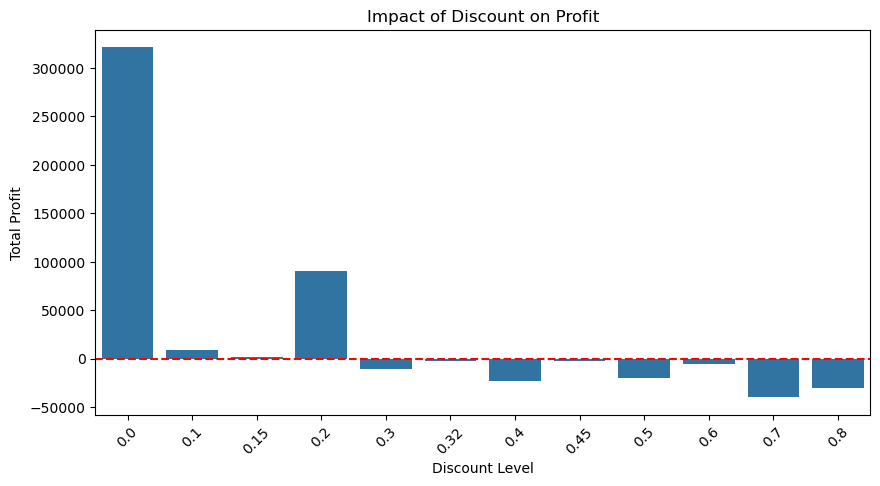

In [53]:
# Visualize discount vs profit
plt.figure(figsize=(10,5))

sns.barplot(
    data=discount_analysis,
    x="Discount",
    y="Profit"
)

plt.title("Impact of Discount on Profit")
plt.xlabel("Discount Level")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)
plt.axhline(y=0, color="red", linestyle="--")

plt.show()

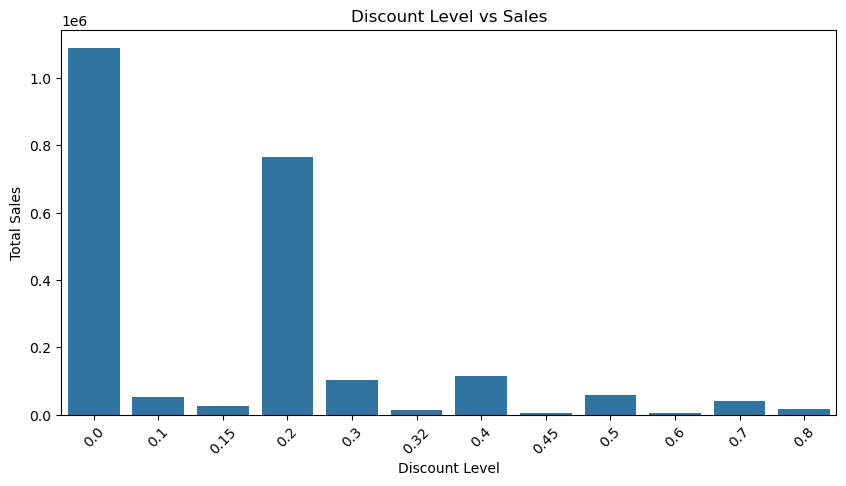

In [54]:
# Visualize discount vs sales
plt.figure(figsize=(10,5))

sns.barplot(
    data=discount_analysis,
    x="Discount",
    y="Sales"
)

plt.title("Discount Level vs Sales")
plt.xlabel("Discount Level")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.show()

In [55]:
# Identify the most profitable discount level
best_discount = discount_analysis.loc[
    discount_analysis["Profit"].idxmax()
]

print("Most Profitable Discount Level:")
print(best_discount)

Most Profitable Discount Level:
Discount         0.000000e+00
Sales            1.087908e+06
Profit           3.209876e+05
Order ID         4.798000e+03
Profit Margin    2.950502e+01
Name: 0, dtype: float64


In [56]:
# identify the discount level with the lowest profit
worst_discount = discount_analysis.loc[
    discount_analysis["Profit"].idxmin()
]

print("Lowest Profit Discount Level:")
print(worst_discount)

Lowest Profit Discount Level:
Discount             0.70000
Sales            40620.28200
Profit          -40075.35690
Order ID           418.00000
Profit Margin      -98.65849
Name: 10, dtype: float64


In [57]:
df.to_csv("Superstore_Cleaned.csv", index=False)